# 勇者傳說 — Battle Effects Generator (T4 GPU)

Generate pixel art battle effect sprites using **SDXL + pixel-art-xl LoRA** on Colab T4.

| Category | Count | Size | Steps |
|----------|-------|------|-------|
| Magic circles | 6 | 128×128 | 25 |
| Elemental particles | 4 | 64×64 | 25 |
| Impact effects | 2 | 128×128 | 25 |

**Output**: `effects/` → 12 RGBA PNGs

## 1. Setup

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [2]:
class ProgressTracker:
    """Track completed items so we can resume after interruption."""

    def __init__(self, name: str, base_dir: Path):
        self.path = base_dir / f'_progress_{name}.json'
        self.done: set = set()
        if self.path.exists():
            self.done = set(json.loads(self.path.read_text()))
            print(f'[progress] Loaded {len(self.done)} completed items from {self.path.name}')

    def is_done(self, key: str) -> bool:
        return key in self.done

    def mark_done(self, key: str):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done), indent=2))

    def summary(self, total: int) -> str:
        return f'{len(self.done)}/{total} done'


def free_vram():
    """Free VRAM by running garbage collection."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    """Print current VRAM usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0)
        total_gb = (getattr(total, 'total_memory', None) or getattr(total, 'total_mem', 0)) / 1024**3
        print(f'VRAM: {used:.1f} / {total_gb:.1f} GB')
    else:
        print('No GPU')

## 3. Prompt Data

In [3]:
PROMPTS = {
    "_meta": {
        "style_prefix_xl": "16-bit pixel art VFX sprite, game special effect",
        "style_suffix_effect_xl": "glowing energy, clean edges, isolated on black background, transparent edges",
        "negative_prompt_xl": "blurry, gradient, soft, realistic, 3d, character, creature, face, text, watermark"
    },
    "magic_circles": [
        {"name": "fx_magic_circle_fire", "prompt_xl": "magical fire runic circle, orange-red glowing arcane symbols arranged in circle, flame runes, ritual magic sigil, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_magic_circle_ice", "prompt_xl": "magical ice crystalline circle, blue frost runes, hexagonal snowflake pattern, icy arcane sigil, cold glow, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_magic_circle_lightning", "prompt_xl": "magical lightning electric circle, yellow electric runes, spark patterns, crackling energy sigil, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_magic_circle_heal", "prompt_xl": "magical healing nature circle, green glowing leaf motifs, life runes, verdant arcane sigil, gentle glow, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_magic_circle_dark", "prompt_xl": "magical dark shadow circle, purple occult runes, shadowy arcane symbols, evil ritual sigil, ominous glow, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_magic_circle_holy", "prompt_xl": "magical holy divine circle, golden light runes, divine symbols, sacred arcane sigil, radiant glow, angelic, top-down view", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
    ],
    "particles": [
        {"name": "fx_fire_burst", "prompt_xl": "fire burst particle sprite, bright flame explosion, orange-red fire ball, pixel art fireball VFX, isolated", "size": 64, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_ice_shard", "prompt_xl": "ice crystal shard sprite, sharp blue ice fragment, frozen spike, pixel art icicle VFX, crystalline", "size": 64, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_lightning_bolt", "prompt_xl": "electric bolt sprite, bright yellow lightning strike, jagged electric bolt, pixel art thunder VFX", "size": 64, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_dark_orb", "prompt_xl": "dark energy sphere sprite, purple-black orb with swirling shadows, evil magic ball, pixel art dark magic VFX", "size": 64, "steps_xl": 25, "guidance_xl": 8.0},
    ],
    "impacts": [
        {"name": "fx_slash_arc", "prompt_xl": "sword slash arc sprite, bright white-yellow crescent slash trail with sparkles, weapon swing VFX, pixel art attack effect", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
        {"name": "fx_impact_star", "prompt_xl": "star burst impact sprite, bright white-gold starburst explosion, radial impact lines, pixel art hit effect VFX", "size": 128, "steps_xl": 25, "guidance_xl": 8.0},
    ],
}

## 4. Load SDXL Pipeline + LoRA

In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE}, {DTYPE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if model_path == SDXL_HUB:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.85])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.85)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda, torch.float16)...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.85)
[pipeline] Ready in 132.3s
VRAM: 6.7 / 14.6 GB


## 5. Post-Processing

In [5]:
from PIL import Image
import numpy as np

def remove_dark_background(image, threshold=30):
    """Remove near-black background while preserving glow halos.
    Uses alpha based on brightness — dark pixels become transparent,
    bright/glowing pixels stay opaque."""
    arr = np.array(image.convert('RGB'))
    # Calculate brightness (max channel value)
    brightness = arr.max(axis=2)
    # Smooth alpha: fully transparent below threshold, fully opaque above 2×threshold
    alpha = np.clip((brightness.astype(float) - threshold) / threshold * 255, 0, 255).astype(np.uint8)
    rgba = np.dstack([arr, alpha])
    return Image.fromarray(rgba, 'RGBA')


def build_prompt(entry, meta, category):
    prompt = entry.get('prompt_xl', entry.get('prompt', ''))
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_effect_xl', '')
    if prefix:
        prompt = f'{prefix}, {prompt}'
    if suffix:
        prompt = f'{prompt}, {suffix}'
    neg = entry.get('negative_prompt', meta.get('negative_prompt_xl', ''))
    return prompt, neg


def postprocess(image, entry, category, do_rembg=True):
    target = entry.get('size', 128)
    # For effects, use brightness-based bg removal instead of rembg
    image = remove_dark_background(image)
    if image.mode == 'RGBA':
        bbox = image.getbbox()
        if bbox:
            # Add small padding
            pad = 8
            l, t, r, b = bbox
            l = max(0, l - pad)
            t = max(0, t - pad)
            r = min(image.width, r + pad)
            b = min(image.height, b + pad)
            image = image.crop((l, t, r, b))
    # Resize to target with NEAREST (pixel art)
    w, h = image.size
    scale = min(target / w, target / h)
    nw, nh = int(w * scale), int(h * scale)
    image = image.resize((nw, nh), Image.NEAREST)
    # Center on transparent canvas
    canvas = Image.new('RGBA', (target, target), (0, 0, 0, 0))
    canvas.paste(image, ((target - nw) // 2, (target - nh) // 2),
                 image if image.mode == 'RGBA' else None)
    return canvas


def generate_one(entry, meta, category, out_dir, tracker):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    prompt, neg = build_prompt(entry, meta, category)
    steps = entry.get('steps_xl', 25)
    guidance = entry.get('guidance_xl', 8.0)

    print(f'  [gen] {name} (256x256, {steps} steps)')
    t0 = time.time()

    # Generate at 512×512 (smallest practical SDXL resolution for effects)
    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=512,
        num_inference_steps=steps, guidance_scale=guidance,
    )
    image = result.images[0]
    image = postprocess(image, entry, category)
    image.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

## 6. Test: Generate 1 Effect

Prompt: 16-bit pixel art VFX sprite, game special effect, magical fire runic circle, orange-red glowing arcane symbols arranged ...


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


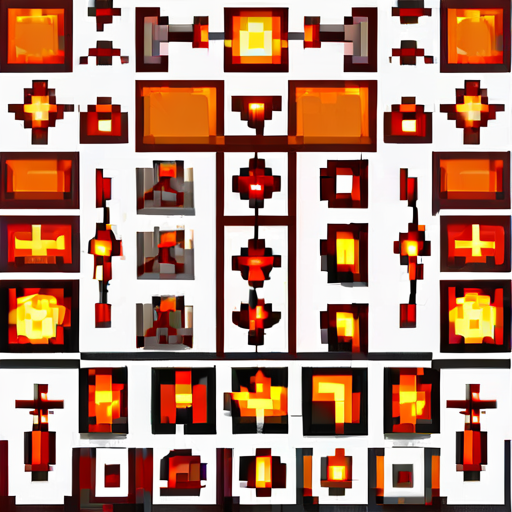

/tmp/ipykernel_344/3030892696.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgba, 'RGBA')


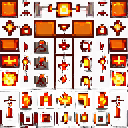

In [6]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['magic_circles'][0]
prompt, neg = build_prompt(test_entry, meta, 'magic_circles')
print(f'Prompt: {prompt[:120]}...')

result = pipe(prompt=prompt, negative_prompt=neg, width=512, height=512,
              num_inference_steps=25, guidance_scale=8.0)
display(result.images[0])
test_img = postprocess(result.images[0], test_entry, 'magic_circles')
display(test_img)
free_vram()

## 7. Generate Magic Circles (6 sprites)

~6-8s per sprite on T4

In [7]:
entries = PROMPTS['magic_circles']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'effects'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('effects_circles', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nMagic circles: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'magic_circles', out_dir, tracker)

print(f'\nDone!')


Magic circles: 6 total, 6 to generate

[1/6] 0/6 done
  [gen] fx_magic_circle_fire (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_344/3030892696.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgba, 'RGBA')


        saved: fx_magic_circle_fire.png (19 KB, 9.1s)

[2/6] 1/6 done
  [gen] fx_magic_circle_ice (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

...

        saved: fx_magic_circle_heal.png (22 KB, 9.1s)

[5/6] 4/6 done
  [gen] fx_magic_circle_dark (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: fx_magic_circle_dark.png (19 KB, 8.0s)

[6/6] 5/6 done
  [gen] fx_magic_circle_holy (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: fx_magic_circle_holy.png (16 KB, 8.9s)

Done!


## 8. Generate Elemental Particles (4 sprites)

In [8]:
entries = PROMPTS['particles']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'effects'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('effects_particles', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nElemental particles: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'particles', out_dir, tracker)

print(f'\nDone!')


Elemental particles: 4 total, 4 to generate

[1/4] 0/4 done
  [gen] fx_fire_burst (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_344/3030892696.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgba, 'RGBA')


        saved: fx_fire_burst.png (7 KB, 9.1s)

[2/4] 1/4 done
  [gen] fx_ice_shard (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: fx_ice_shard.png (3 KB, 8.1s)

[3/4] 2/4 done
  [gen] fx_lightning_bolt (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: fx_lightning_bolt.png (7 KB, 9.0s)

[4/4] 3/4 done
  [gen] fx_dark_orb (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

        saved: fx_dark_orb.png (8 KB, 9.1s)

Done!


## 9. Generate Impact Effects (2 sprites)

In [ ]:
entries = PROMPTS['impacts']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'effects'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('effects_impacts', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nImpact effects: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'impacts', out_dir, tracker)

print(f'\nDone!')


Impact effects: 2 total, 2 to generate

[1/2] 0/2 done
  [gen] fx_slash_arc (256x256, 25 steps)


  0%|          | 0/25 [00:00<?, ?it/s]

## 10. Quality Review

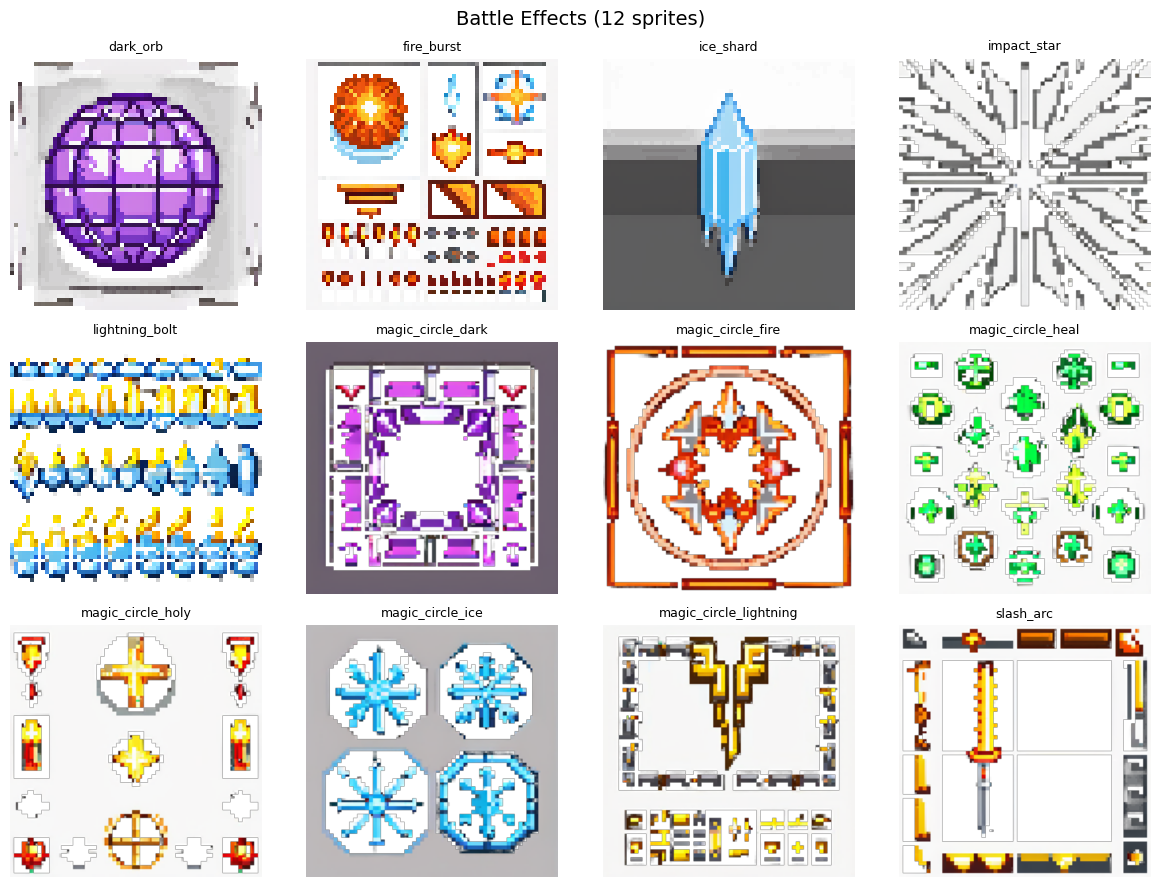

In [ ]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'effects'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 4
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
for ax in axes.flat:
    ax.axis('off')

for i, png in enumerate(pngs):
    r, c = i // cols, i % cols
    ax = axes[r][c] if rows > 1 else axes[c]
    img = Image.open(png)
    ax.imshow(img)
    ax.set_title(png.stem.replace('fx_', ''), fontsize=9)

plt.suptitle(f'Battle Effects ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Generate Manifest + Download

In [ ]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'effects'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['effects'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/effects_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')